In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
print("=" * 50)
print("数据加载与预处理")
print("=" * 50)

data_path='winequality-red.csv'
df = pd.read_csv(data_path)
print(f"数据集形状: {df.shape}")
print(f"\n前5行数据:\n{df.head()}")
print(f"\n数据基本信息:\n{df.info()}")
print(f"\n缺失值统计:\n{df.isnull().sum()}")


数据加载与预处理
数据集形状: (1599, 12)

前5行数据:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      

In [4]:
# 质量评分分布
print(f"\n质量评分分布:\n{df['quality'].value_counts().sort_index()}")


质量评分分布:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [5]:
# 创建多分类标签：低质量(3-4)、中等质量(5-6)、高质量(7-8)
def quality_to_class(quality):
    if quality <= 4:
        return 0  # 低质量
    elif quality <= 6:
        return 1  # 中等质量
    else:
        return 2  # 高质量

df['quality_class'] = df['quality'].apply(quality_to_class)
print(f"\n质量类别分布:\n{df['quality_class'].value_counts().sort_index()}")

# 特征和标签分离
X = df.drop(['quality', 'quality_class'], axis=1).values
y = df['quality_class'].values
feature_names = df.drop(['quality', 'quality_class'], axis=1).columns.tolist()

print(f"\n特征数量: {X.shape[1]}")
print(f"样本数量: {X.shape[0]}")


质量类别分布:
quality_class
0      63
1    1319
2     217
Name: count, dtype: int64

特征数量: 11
样本数量: 1599


In [6]:
print("\n" + "=" * 50)
print("初级要求：分层采样数据集划分")
print("=" * 50)

def stratified_train_test_split(X, y, test_size=0.3, random_state=42):
    """
    手动实现分层采样
    """
    np.random.seed(random_state)
    
    # 获取所有类别
    classes = np.unique(y)
    
    train_indices = []
    test_indices = []
    
    for cls in classes:
        # 获取当前类别的所有索引
        cls_indices = np.where(y == cls)[0]
        
        # 随机打乱
        np.random.shuffle(cls_indices)
        
        # 计算测试集大小
        n_test = int(len(cls_indices) * test_size)
        
        # 分割
        test_indices.extend(cls_indices[:n_test])
        train_indices.extend(cls_indices[n_test:])
    
    # 转换为numpy数组并打乱
    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)
    
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

# 划分数据集
X_train, X_test, y_train, y_test = stratified_train_test_split(X, y, test_size=0.3, random_state=42)

print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")
print(f"\n训练集类别分布: {Counter(y_train)}")
print(f"测试集类别分布: {Counter(y_test)}")


初级要求：分层采样数据集划分
训练集大小: 1121
测试集大小: 478

训练集类别分布: Counter({np.int64(1): 924, np.int64(2): 152, np.int64(0): 45})
测试集类别分布: Counter({np.int64(1): 395, np.int64(2): 65, np.int64(0): 18})


In [7]:
# 数据标准化（Z-score标准化）
def z_score_normalize(X_train, X_test):
    """
    手动实现Z-score标准化
    """
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    
    X_train_normalized = (X_train - mean) / (std + 1e-8)
    X_test_normalized = (X_test - mean) / (std + 1e-8)
    
    return X_train_normalized, X_test_normalized, mean, std

X_train_norm, X_test_norm, train_mean, train_std = z_score_normalize(X_train, X_test)
print(f"\n标准化后训练集均值: {np.mean(X_train_norm, axis=0)[:3]}")
print(f"标准化后训练集标准差: {np.std(X_train_norm, axis=0)[:3]}")


标准化后训练集均值: [ 4.98669398e-15  4.89409286e-15 -1.24659922e-15]
标准化后训练集标准差: [0.99999999 0.99999995 0.99999995]


In [8]:
# ==================== 初级要求：手动实现高斯朴素贝叶斯 ====================
print("\n" + "=" * 50)
print("初级要求：手动实现高斯朴素贝叶斯分类器")
print("=" * 50)

class GaussianNaiveBayes:
    """
    手动实现高斯朴素贝叶斯分类器
    """
    def __init__(self):
        self.classes = None
        self.class_prior = {}  # 类先验概率 P(c)
        self.mean = {}  # 每个类别每个特征的均值
        self.var = {}   # 每个类别每个特征的方差
        
    def fit(self, X, y):
        """
        训练模型
        """
        self.classes = np.unique(y)
        n_samples = X.shape[0]
        
        for cls in self.classes:
            # 获取当前类别的样本
            X_cls = X[y == cls]
            
            # 计算类先验概率 P(c)
            self.class_prior[cls] = len(X_cls) / n_samples
            
            # 计算每个特征的均值和方差
            self.mean[cls] = np.mean(X_cls, axis=0)
            self.var[cls] = np.var(X_cls, axis=0) + 1e-9  # 添加小常数避免除零
            
        print(f"训练完成！")
        print(f"类别: {self.classes}")
        print(f"类先验概率: {self.class_prior}")
        
    def _gaussian_probability(self, x, mean, var):
        """
        计算高斯概率密度函数
        P(x|c) = 1/sqrt(2*pi*var) * exp(-(x-mean)^2 / (2*var))
        """
        eps = 1e-9
        coeff = 1.0 / np.sqrt(2.0 * np.pi * var + eps)
        exponent = np.exp(-(x - mean) ** 2 / (2 * var + eps))
        return coeff * exponent
    
    def _predict_log_proba(self, x):
        """
        使用对数概率避免数值下溢
        log P(c|x) = log P(c) + sum(log P(x_i|c))
        """
        log_probs = {}
        
        for cls in self.classes:
            # 计算对数先验概率
            log_prior = np.log(self.class_prior[cls])
            
            # 计算对数似然
            log_likelihood = np.sum(np.log(
                self._gaussian_probability(x, self.mean[cls], self.var[cls]) + 1e-9
            ))
            
            log_probs[cls] = log_prior + log_likelihood
            
        return log_probs
    
    def predict(self, X):
        """
        预测类别
        """
        predictions = []
        for x in X:
            log_probs = self._predict_log_proba(x)
            # 选择概率最大的类别
            pred_class = max(log_probs, key=log_probs.get)
            predictions.append(pred_class)
        return np.array(predictions)
    
    def predict_proba(self, X):
        """
        预测概率
        """
        probas = []
        for x in X:
            log_probs = self._predict_log_proba(x)
            
            # 将对数概率转换为概率（使用log-sum-exp技巧避免溢出）
            log_probs_array = np.array([log_probs[cls] for cls in self.classes])
            max_log_prob = np.max(log_probs_array)
            exp_probs = np.exp(log_probs_array - max_log_prob)
            probs = exp_probs / np.sum(exp_probs)
            
            probas.append(probs)
        return np.array(probas)


初级要求：手动实现高斯朴素贝叶斯分类器


In [9]:
# 训练自定义朴素贝叶斯分类器
custom_nb = GaussianNaiveBayes()
custom_nb.fit(X_train_norm, y_train)

# 预测
y_pred_custom = custom_nb.predict(X_test_norm)
y_pred_proba_custom = custom_nb.predict_proba(X_test_norm)

# 计算准确率
accuracy_custom = np.mean(y_pred_custom == y_test)
print(f"\n自定义朴素贝叶斯准确率: {accuracy_custom:.4f}")

训练完成！
类别: [0 1 2]
类先验概率: {np.int64(0): 0.04014272970561998, np.int64(1): 0.8242640499553969, np.int64(2): 0.13559322033898305}

自定义朴素贝叶斯准确率: 0.7615


In [10]:
# 与sklearn对比
from sklearn.naive_bayes import GaussianNB
sklearn_nb = GaussianNB()
sklearn_nb.fit(X_train_norm, y_train)
y_pred_sklearn = sklearn_nb.predict(X_test_norm)
accuracy_sklearn = np.mean(y_pred_sklearn == y_test)
print(f"sklearn朴素贝叶斯准确率: {accuracy_sklearn:.4f}")

sklearn朴素贝叶斯准确率: 0.7531


In [11]:
print("\n" + "=" * 50)
print("中级要求：分类器性能深入评估")
print("=" * 50)

def calculate_confusion_matrix(y_true, y_pred, n_classes):
    """
    手动计算混淆矩阵
    """
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1
    return cm

def calculate_metrics(y_true, y_pred, n_classes):
    """
    手动计算精确率、召回率、F1分数
    """
    cm = calculate_confusion_matrix(y_true, y_pred, n_classes)
    
    metrics = {}
    for cls in range(n_classes):
        # True Positive
        tp = cm[cls, cls]
        # False Positive
        fp = np.sum(cm[:, cls]) - tp
        # False Negative
        fn = np.sum(cm[cls, :]) - tp
        # True Negative
        tn = np.sum(cm) - tp - fp - fn
        
        # 精确率 Precision = TP / (TP + FP)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        
        # 召回率 Recall = TP / (TP + FN)
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        # F1分数 = 2 * (Precision * Recall) / (Precision + Recall)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        # 支持度
        support = np.sum(y_true == cls)
        
        metrics[cls] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': support
        }
    
    return metrics, cm


中级要求：分类器性能深入评估


In [12]:
# 计算指标
metrics_custom, cm_custom = calculate_metrics(y_test, y_pred_custom, len(np.unique(y_test)))

print("\n自定义朴素贝叶斯详细性能指标:")
print(f"{'类别':<10} {'精确率':<10} {'召回率':<10} {'F1分数':<10} {'支持度':<10}")
print("-" * 50)
for cls in sorted(metrics_custom.keys()):
    m = metrics_custom[cls]
    print(f"{cls:<10} {m['precision']:<10.4f} {m['recall']:<10.4f} {m['f1']:<10.4f} {m['support']:<10}")

# 计算宏平均和加权平均
macro_precision = np.mean([m['precision'] for m in metrics_custom.values()])
macro_recall = np.mean([m['recall'] for m in metrics_custom.values()])
macro_f1 = np.mean([m['f1'] for m in metrics_custom.values()])

total_support = sum([m['support'] for m in metrics_custom.values()])
weighted_precision = sum([m['precision'] * m['support'] for m in metrics_custom.values()]) / total_support
weighted_recall = sum([m['recall'] * m['support'] for m in metrics_custom.values()]) / total_support
weighted_f1 = sum([m['f1'] * m['support'] for m in metrics_custom.values()]) / total_support

print(f"\n{'宏平均':<10} {macro_precision:<10.4f} {macro_recall:<10.4f} {macro_f1:<10.4f} {total_support:<10}")
print(f"{'加权平均':<10} {weighted_precision:<10.4f} {weighted_recall:<10.4f} {weighted_f1:<10.4f} {total_support:<10}")



自定义朴素贝叶斯详细性能指标:
类别         精确率        召回率        F1分数       支持度       
--------------------------------------------------
0          0.2727     0.1667     0.2069     18        
1          0.8828     0.8203     0.8504     395       
2          0.3700     0.5692     0.4485     65        

宏平均        0.5085     0.5187     0.5019     478       
加权平均       0.7901     0.7615     0.7715     478       


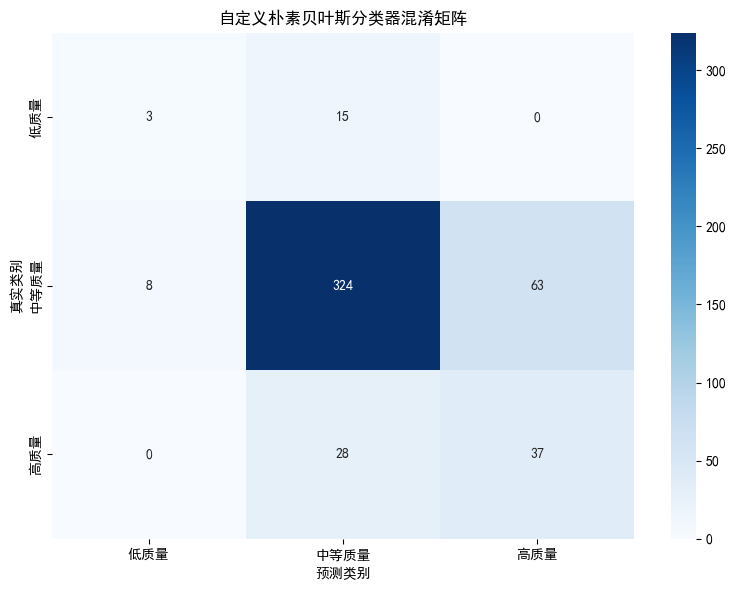

In [13]:
# 可视化混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['低质量', '中等质量', '高质量'],
            yticklabels=['低质量', '中等质量', '高质量'])
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title('自定义朴素贝叶斯分类器混淆矩阵')
plt.tight_layout()
plt.savefig('confusion_matrix_custom.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
print("\n" + "=" * 50)
print("中级要求：特征重要性分析")
print("=" * 50)

def calculate_anova_f_score(X, y):
    """
    手动计算ANOVA F值进行特征重要性分析
    """
    n_features = X.shape[1]
    classes = np.unique(y)
    f_scores = []
    
    for feature_idx in range(n_features):
        feature_values = X[:, feature_idx]
        
        # 总体均值
        overall_mean = np.mean(feature_values)
        
        # 组间平方和 (Between-group sum of squares)
        ss_between = 0
        for cls in classes:
            cls_values = feature_values[y == cls]
            cls_mean = np.mean(cls_values)
            ss_between += len(cls_values) * (cls_mean - overall_mean) ** 2
        
        # 组内平方和 (Within-group sum of squares)
        ss_within = 0
        for cls in classes:
            cls_values = feature_values[y == cls]
            cls_mean = np.mean(cls_values)
            ss_within += np.sum((cls_values - cls_mean) ** 2)
        
        # 自由度
        df_between = len(classes) - 1
        df_within = len(feature_values) - len(classes)
        
        # F统计量
        ms_between = ss_between / df_between
        ms_within = ss_within / df_within if df_within > 0 else 1e-9
        f_score = ms_between / ms_within if ms_within > 0 else 0
        
        f_scores.append(f_score)
    
    return np.array(f_scores)



中级要求：特征重要性分析


In [16]:
# 计算特征重要性
f_scores = calculate_anova_f_score(X_train_norm, y_train)

# 排序
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'F-Score': f_scores
}).sort_values('F-Score', ascending=False)

print("\n特征重要性排序（基于ANOVA F值）:")
print(feature_importance_df)


特征重要性排序（基于ANOVA F值）:
                 Feature     F-Score
10               alcohol  115.173316
1       volatile acidity   85.978524
2            citric acid   47.026932
9              sulphates   24.935257
6   total sulfur dioxide   17.994755
0          fixed acidity   13.508130
7                density   10.870391
8                     pH    8.336745
5    free sulfur dioxide    7.069030
4              chlorides    6.595375
3         residual sugar    1.959445


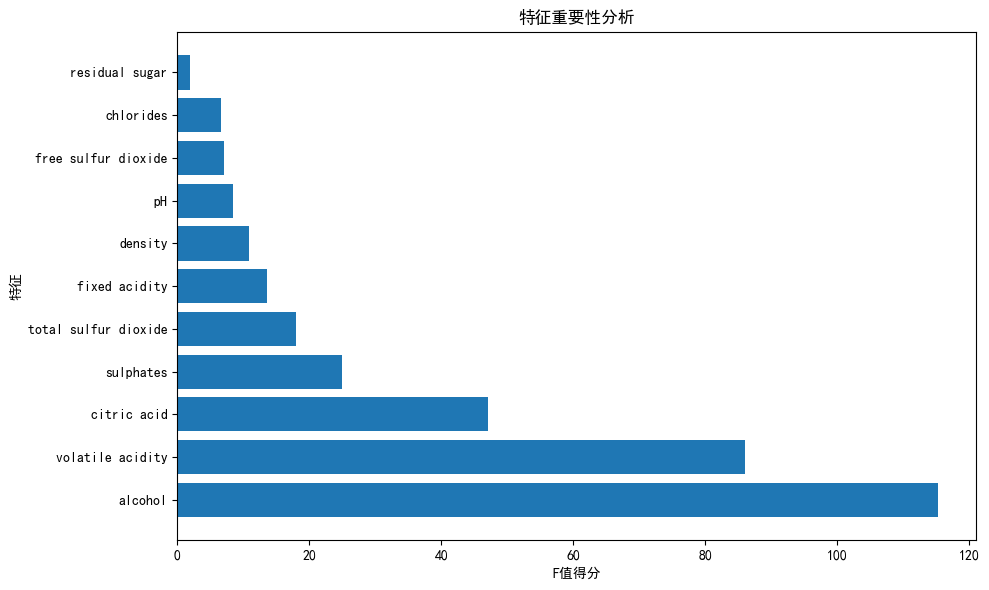

In [17]:
# 可视化特征重要性
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['F-Score'])
plt.xlabel('F值得分')
plt.ylabel('特征')
plt.title('特征重要性分析')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
print("\n" + "=" * 50)
print("高级要求：ROC曲线与AUC分析")
print("=" * 50)

def calculate_roc_curve(y_true, y_scores, pos_label):
    """
    手动计算ROC曲线
    """
    # 将多分类问题转换为二分类（一对多）
    y_true_binary = (y_true == pos_label).astype(int)
    
    # 获取所有可能的阈值
    thresholds = np.unique(y_scores)
    thresholds = np.sort(thresholds)[::-1]  # 降序排列
    
    tpr_list = []  # True Positive Rate
    fpr_list = []  # False Positive Rate
    
    for threshold in thresholds:
        y_pred_binary = (y_scores >= threshold).astype(int)
        
        # 计算TP, FP, TN, FN
        tp = np.sum((y_pred_binary == 1) & (y_true_binary == 1))
        fp = np.sum((y_pred_binary == 1) & (y_true_binary == 0))
        tn = np.sum((y_pred_binary == 0) & (y_true_binary == 0))
        fn = np.sum((y_pred_binary == 0) & (y_true_binary == 1))
        
        # 计算TPR和FPR
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    
    # 添加起点和终点
    fpr_list = [0] + fpr_list + [1]
    tpr_list = [0] + tpr_list + [1]
    
    return np.array(fpr_list), np.array(tpr_list), thresholds

def calculate_auc(fpr, tpr):
    """
    手动计算AUC（使用梯形法则）
    """
    auc = 0
    for i in range(len(fpr) - 1):
        # 梯形面积 = (上底 + 下底) * 高 / 2
        auc += (tpr[i] + tpr[i + 1]) * (fpr[i + 1] - fpr[i]) / 2
    return auc



高级要求：ROC曲线与AUC分析


类别 0 (低质量) AUC: 0.6984
类别 1 (中等质量) AUC: 0.7329
类别 2 (高质量) AUC: 0.8068


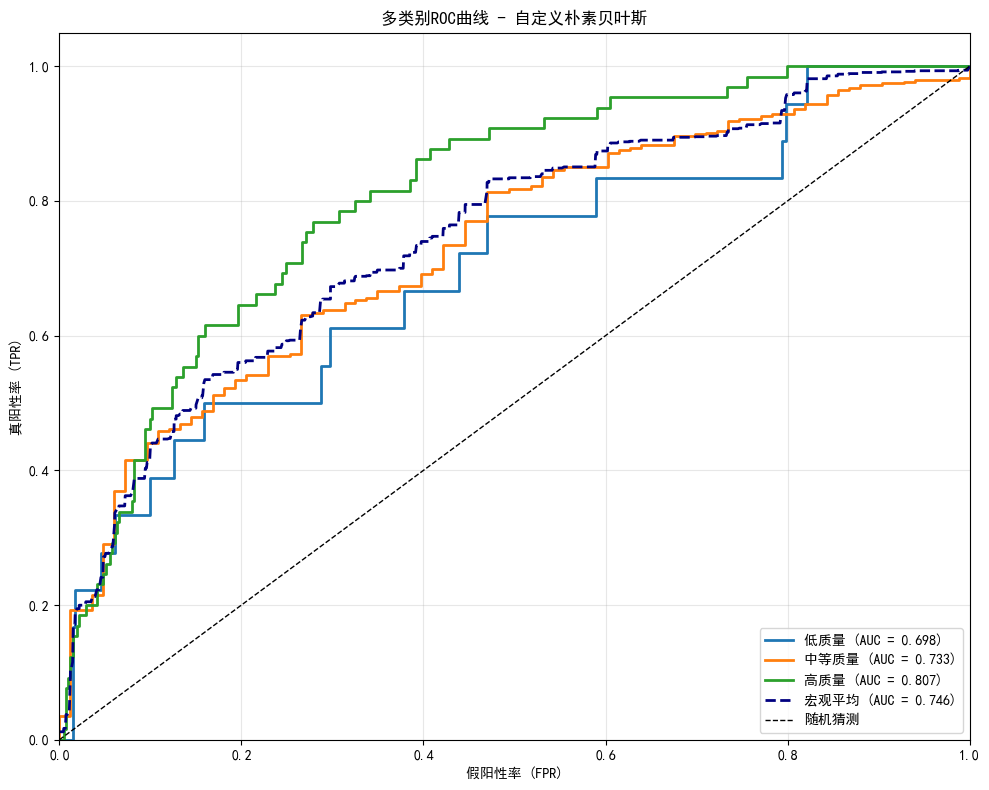

In [21]:
# 计算每个类别的ROC曲线和AUC
classes = np.unique(y_test)
roc_data = {}

plt.figure(figsize=(10, 8))

for cls in classes:
    # 获取该类别的预测概率
    y_scores = y_pred_proba_custom[:, cls]
    
    # 计算ROC曲线
    fpr, tpr, thresholds = calculate_roc_curve(y_test, y_scores, cls)
    
    # 计算AUC
    auc = calculate_auc(fpr, tpr)
    
    roc_data[cls] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}
    
    # 绘制ROC曲线
    class_names = ['低质量', '中等质量', '高质量']
    plt.plot(fpr, tpr, linewidth=2, label=f'{class_names[cls]} (AUC = {auc:.3f})')
    
    print(f"类别 {cls} ({class_names[cls]}) AUC: {auc:.4f}")

# 计算宏观平均ROC
all_fpr = np.unique(np.concatenate([roc_data[cls]['fpr'] for cls in classes]))
mean_tpr = np.zeros_like(all_fpr)

for cls in classes:
    mean_tpr += np.interp(all_fpr, roc_data[cls]['fpr'], roc_data[cls]['tpr'])

mean_tpr /= len(classes)
macro_auc = calculate_auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr, linewidth=2, linestyle='--', 
         label=f'宏观平均 (AUC = {macro_auc:.3f})', color='navy')

# 绘制对角线
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率 (FPR)')
plt.ylabel('真阳性率 (TPR)')
plt.title('多类别ROC曲线 - 自定义朴素贝叶斯')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_custom.png', dpi=300, bbox_inches='tight')
plt.show()



高级要求：概率校准分析


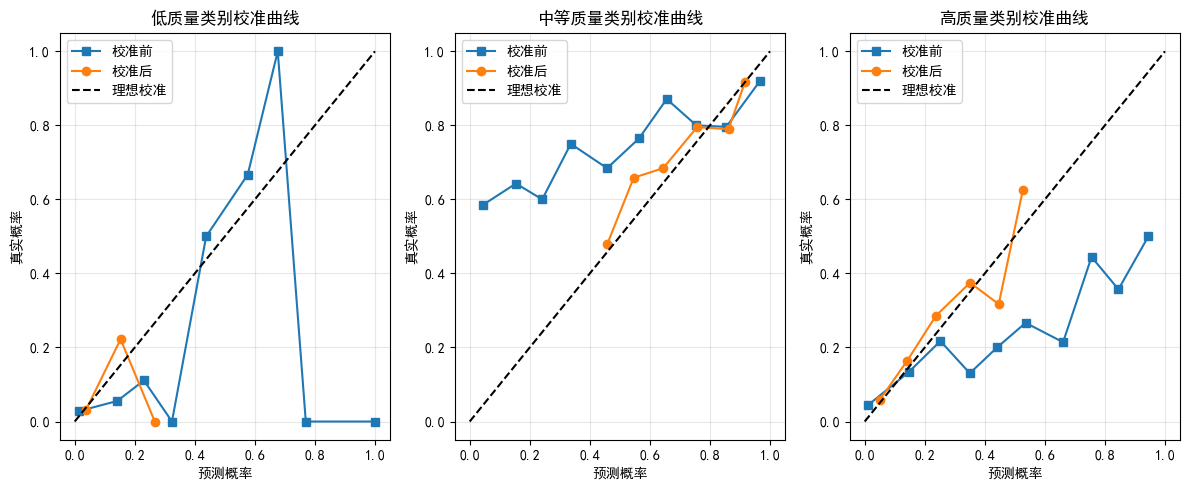

In [23]:
print("\n" + "=" * 50)
print("高级要求：概率校准分析")
print("=" * 50)

from sklearn.calibration import CalibratedClassifierCV

# 使用Platt scaling进行概率校准（这里可以调用sklearn）
calibrated_nb = CalibratedClassifierCV(sklearn_nb, method='sigmoid', cv=5)
calibrated_nb.fit(X_train_norm, y_train)
y_pred_proba_calibrated = calibrated_nb.predict_proba(X_test_norm)

# 绘制校准曲线
from sklearn.calibration import calibration_curve

plt.figure(figsize=(12, 5))

for i, cls in enumerate(classes):
    plt.subplot(1, 3, i + 1)
    
    # 校准前
    y_true_binary = (y_test == cls).astype(int)
    prob_true_before, prob_pred_before = calibration_curve(
        y_true_binary, y_pred_proba_custom[:, cls], n_bins=10
    )
    
    # 校准后
    prob_true_after, prob_pred_after = calibration_curve(
        y_true_binary, y_pred_proba_calibrated[:, cls], n_bins=10
    )
    
    plt.plot(prob_pred_before, prob_true_before, 's-', label='校准前')
    plt.plot(prob_pred_after, prob_true_after, 'o-', label='校准后')
    plt.plot([0, 1], [0, 1], 'k--', label='理想校准')
    
    class_names = ['低质量', '中等质量', '高质量']
    plt.xlabel('预测概率')
    plt.ylabel('真实概率')
    plt.title(f'{class_names[cls]}类别校准曲线')
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()


高级要求：模型比较研究

模型性能比较:
模型              准确率        宏平均F1        加权平均F1      
--------------------------------------------------
朴素贝叶斯           0.7531     0.4915       0.7656      
逻辑回归            0.8347     0.4366       0.8033      
随机森林            0.8515     0.4760       0.8254      
支持向量机           0.8285     0.4164       0.7929      


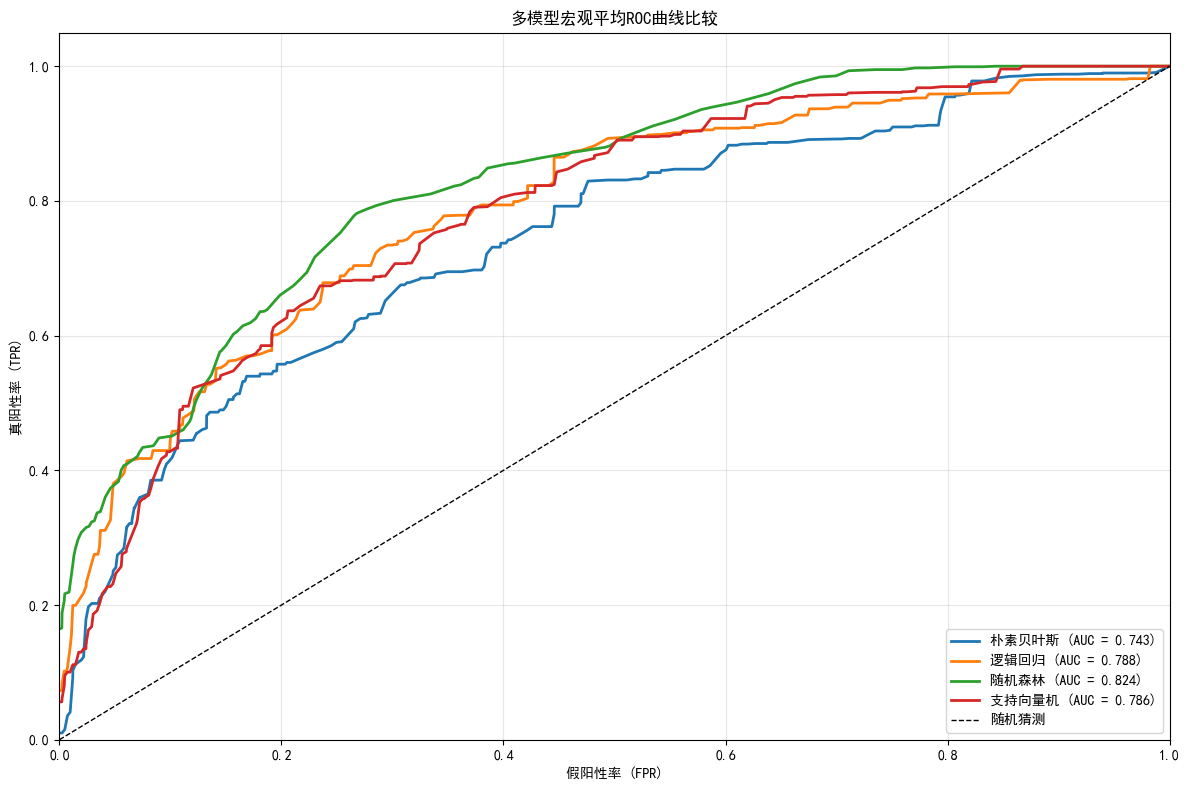


实验完成！


In [ ]:
print("\n" + "=" * 50)
print("高级要求：模型比较研究")
print("=" * 50)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc

# 训练其他分类器（可以调用sklearn）
models = {
    '朴素贝叶斯': sklearn_nb,
    '逻辑回归': LogisticRegression(max_iter=1000, random_state=42),
    '随机森林': RandomForestClassifier(n_estimators=100, random_state=42),
    '支持向量机': SVC(kernel='rbf', probability=True, random_state=42)
}

# 训练模型
for name, model in models.items():
    if name != '朴素贝叶斯':  # 朴素贝叶斯已经训练过了
        model.fit(X_train_norm, y_train)

# 比较性能
print("\n模型性能比较:")
print(f"{'模型':<15} {'准确率':<10} {'宏平均F1':<12} {'加权平均F1':<12}")
print("-" * 50)

from sklearn.metrics import f1_score

for name, model in models.items():
    y_pred = model.predict(X_test_norm)
    accuracy = np.mean(y_pred == y_test)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"{name:<15} {accuracy:<10.4f} {macro_f1:<12.4f} {weighted_f1:<12.4f}")

# 绘制多模型ROC曲线比较
plt.figure(figsize=(12, 8))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test_norm)
    
    # 计算宏观平均ROC
    fpr_list = []
    tpr_list = []
    
    for cls in classes:
        y_true_binary = (y_test == cls).astype(int)
        fpr, tpr, _ = roc_curve(y_true_binary, y_pred_proba[:, cls])
        fpr_list.append(fpr)
        tpr_list.append(tpr)
    
    # 计算宏观平均
    all_fpr = np.unique(np.concatenate(fpr_list))
    mean_tpr = np.zeros_like(all_fpr)
    
    for fpr, tpr in zip(fpr_list, tpr_list):
        mean_tpr += np.interp(all_fpr, fpr, tpr)
    
    mean_tpr /= len(classes)
    macro_auc = auc(all_fpr, mean_tpr)
    
    plt.plot(all_fpr, mean_tpr, linewidth=2, label=f'{name} (AUC = {macro_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率 (FPR)')
plt.ylabel('真阳性率 (TPR)')
plt.title('多模型宏观平均ROC曲线比较')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_roc.png', dpi=300, bbox_inches='tight')
plt.show()


In [34]:
# ==================== 深度学习拓展：MLP和1D CNN分类器 ====================
print("\n" + "=" * 50)
print("深度学习拓展：MLP和1D CNN分类器")
print("=" * 50)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 检查GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")


深度学习拓展：MLP和1D CNN分类器
使用设备: cpu


In [35]:
# ==================== Focal Loss实现 ====================
class FocalLoss(nn.Module):
    """
    Focal Loss实现，用于处理类别不平衡问题
    
    Focal Loss = -α * (1 - p_t)^γ * log(p_t)
    
    参数:
        alpha: 类别权重，用于平衡正负样本
        gamma: 聚焦参数，减少易分类样本的权重
        reduction: 'mean', 'sum' 或 'none'
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # 类别权重
        self.gamma = gamma  # 聚焦参数
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        """
        inputs: 模型输出的logits，shape: (batch_size, num_classes)
        targets: 真实标签，shape: (batch_size,)
        """
        # 计算交叉熵
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        # 计算概率
        p = torch.exp(-ce_loss)
        
        # 计算focal loss
        focal_loss = (1 - p) ** self.gamma * ce_loss
        
        # 应用类别权重
        if self.alpha is not None:
            if isinstance(self.alpha, (list, np.ndarray)):
                alpha = torch.tensor(self.alpha, device=inputs.device)
                alpha_t = alpha[targets]
            else:
                alpha_t = self.alpha
            focal_loss = alpha_t * focal_loss
        
        # 归约
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# 计算类别权重（用于Focal Loss的alpha参数）
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # 归一化
print(f"\n类别分布: {class_counts}")
print(f"类别权重: {class_weights}")


类别分布: [ 45 924 152]
类别权重: [0.74363047 0.03621577 0.22015376]


In [36]:
# ==================== MLP分类器实现 ====================
class MLPClassifier(nn.Module):
    """
    多层感知机（MLP）分类器
    """
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], num_classes=3, dropout=0.3):
        super(MLPClassifier, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        # 构建隐藏层
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        
        # 输出层
        layers.append(nn.Linear(prev_dim, num_classes))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

# ==================== 1D CNN分类器实现 ====================
class CNN1DClassifier(nn.Module):
    """
    1D卷积神经网络分类器
    适用于表格数据，将特征视为1D序列
    """
    def __init__(self, input_dim, num_classes=3, dropout=0.3):
        super(CNN1DClassifier, self).__init__()
        
        # 卷积层
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        
        # 全局平均池化
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # 全连接层
        self.fc1 = nn.Linear(256, 128)
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # x shape: (batch_size, input_dim)
        # 转换为 (batch_size, 1, input_dim) 用于1D卷积
        x = x.unsqueeze(1)
        
        # 卷积块1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        
        # 卷积块2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        
        # 卷积块3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        
        # 全局平均池化
        x = self.global_pool(x)
        x = x.squeeze(-1)  # (batch_size, 256)
        
        # 全连接层
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        
        return x


In [42]:
# ==================== 数据准备 ====================
# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train_norm)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_norm)
y_test_tensor = torch.LongTensor(y_test)

# 创建数据加载器
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [43]:
# ==================== 训练函数 ====================
def train_model(model, train_loader, criterion, optimizer, device):
    """训练一个epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 前向传播
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # 反向传播
        loss.backward()
        optimizer.step()
        
        # 统计
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy

def evaluate_model(model, test_loader, criterion, device):
    """评估模型"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            # 保存预测结果
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
            # 保存概率
            probs = F.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(test_loader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_targets), np.array(all_probs)


In [44]:
# ==================== 训练MLP模型 ====================
print("\n" + "=" * 50)
print("训练MLP分类器（使用Focal Loss）")
print("=" * 50)

# 初始化模型
input_dim = X_train_norm.shape[1]
mlp_model = MLPClassifier(input_dim=input_dim, hidden_dims=[128, 64, 32], 
                          num_classes=3, dropout=0.3).to(device)

# 损失函数和优化器
focal_loss = FocalLoss(alpha=class_weights.tolist(), gamma=2.0, reduction='mean')
optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_mlp = optim.lr_scheduler.ReduceLROnPlateau(optimizer_mlp, mode='min', 
                                                      factor=0.5, patience=10)  # 删除verbose参数
# 训练
num_epochs = 100
best_acc = 0
train_losses_mlp = []
test_losses_mlp = []
train_accs_mlp = []
test_accs_mlp = []

print(f"\nMLP模型结构:")
print(mlp_model)
print(f"\n开始训练 (共{num_epochs}个epoch)...")

for epoch in range(num_epochs):
    train_loss, train_acc = train_model(mlp_model, train_loader, focal_loss, 
                                       optimizer_mlp, device)
    test_loss, test_acc, _, _, _ = evaluate_model(mlp_model, test_loader, 
                                                   focal_loss, device)
    
    train_losses_mlp.append(train_loss)
    test_losses_mlp.append(test_loss)
    train_accs_mlp.append(train_acc)
    test_accs_mlp.append(test_acc)
    
    scheduler_mlp.step(test_loss)
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(mlp_model.state_dict(), 'best_mlp_model.pth')
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

print(f"\nMLP最佳测试准确率: {best_acc:.2f}%")

# 加载最佳模型并评估
mlp_model.load_state_dict(torch.load('best_mlp_model.pth'))
_, mlp_acc, mlp_preds, mlp_targets, mlp_probs = evaluate_model(
    mlp_model, test_loader, focal_loss, device)



训练MLP分类器（使用Focal Loss）

MLP模型结构:
MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)

开始训练 (共100个epoch)...
Epoch [10/100] Train Loss: 0.0274, Train Acc: 56.74% | Test Loss: 0.0269, Test Acc: 55.23%
Epoch [20/100] Train Loss: 0.0209, Train Acc: 61.82% | Test Loss: 0.0239, Test Acc: 56.69%
Epoch [30/100] Train Loss: 0.0195, Trai

In [45]:
# ==================== 训练1D CNN模型 ====================
print("\n" + "=" * 50)
print("训练1D CNN分类器（使用Focal Loss）")
print("=" * 50)

# 初始化模型
cnn_model = CNN1DClassifier(input_dim=input_dim, num_classes=3, dropout=0.3).to(device)

# 损失函数和优化器
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_cnn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, mode='min', 
                                                      factor=0.5, patience=10)

# 训练
best_acc = 0
train_losses_cnn = []
test_losses_cnn = []
train_accs_cnn = []
test_accs_cnn = []

print(f"\n1D CNN模型结构:")
print(cnn_model)
print(f"\n开始训练 (共{num_epochs}个epoch)...")

for epoch in range(num_epochs):
    train_loss, train_acc = train_model(cnn_model, train_loader, focal_loss, 
                                       optimizer_cnn, device)
    test_loss, test_acc, _, _, _ = evaluate_model(cnn_model, test_loader, 
                                                   focal_loss, device)
    
    train_losses_cnn.append(train_loss)
    test_losses_cnn.append(test_loss)
    train_accs_cnn.append(train_acc)
    test_accs_cnn.append(test_acc)
    
    scheduler_cnn.step(test_loss)
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(cnn_model.state_dict(), 'best_cnn_model.pth')
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

print(f"\n1D CNN最佳测试准确率: {best_acc:.2f}%")

# 加载最佳模型并评估
cnn_model.load_state_dict(torch.load('best_cnn_model.pth'))
_, cnn_acc, cnn_preds, cnn_targets, cnn_probs = evaluate_model(
    cnn_model, test_loader, focal_loss, device)



训练1D CNN分类器（使用Focal Loss）

1D CNN模型结构:
CNN1DClassifier(
  (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_feature


可视化训练过程


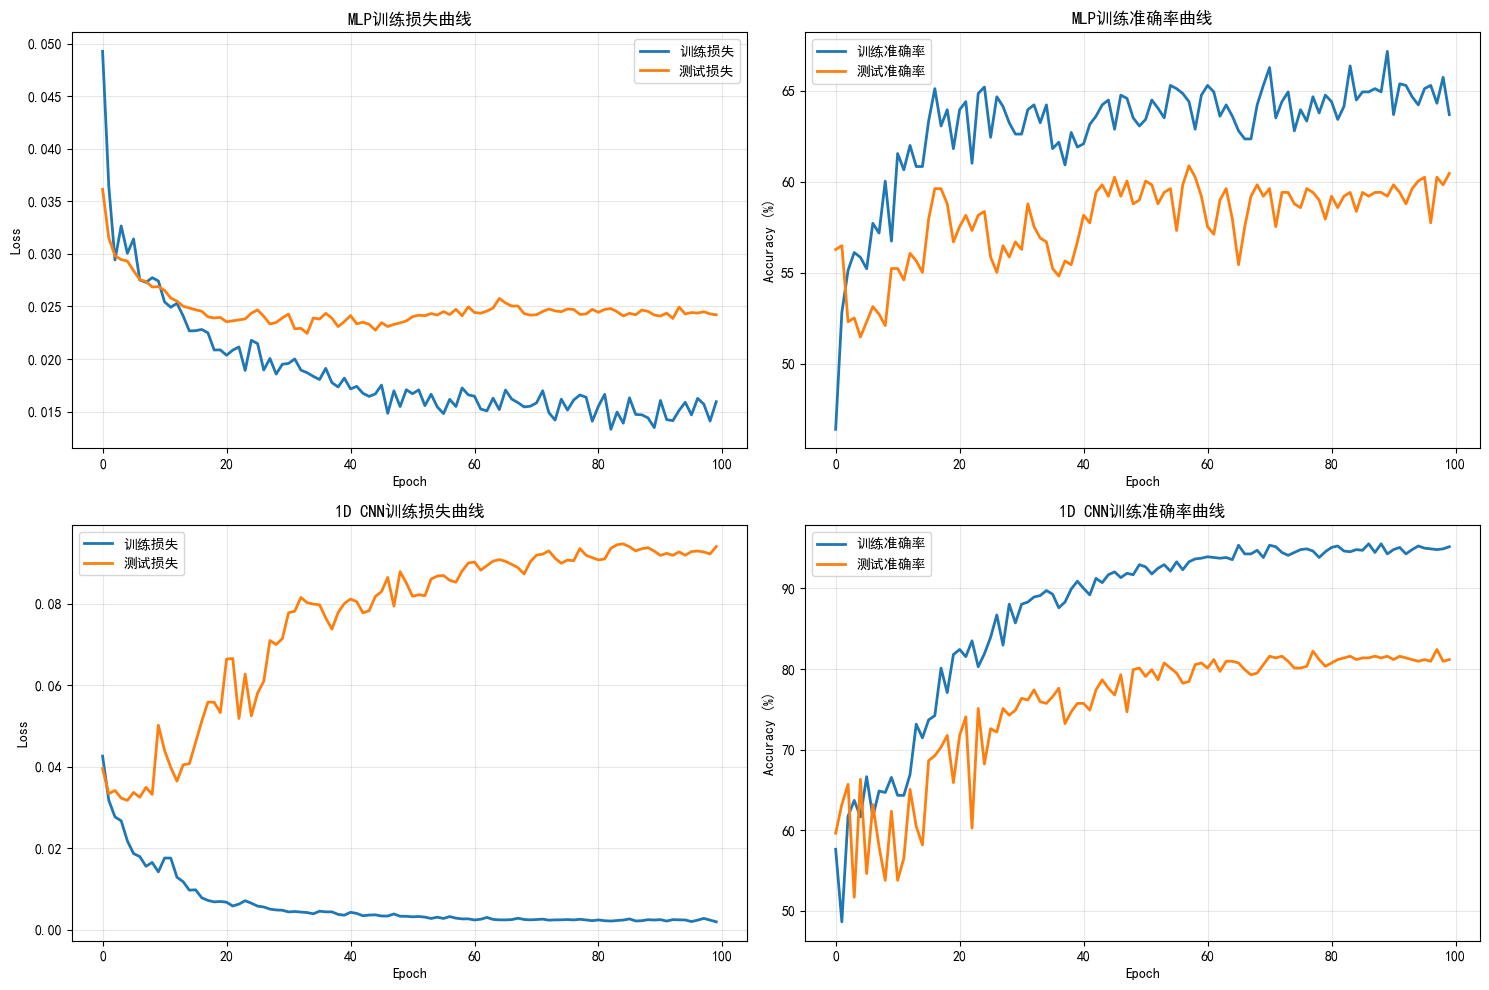

In [46]:
# ==================== 可视化训练过程 ====================
print("\n" + "=" * 50)
print("可视化训练过程")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# MLP损失曲线
axes[0, 0].plot(train_losses_mlp, label='训练损失', linewidth=2)
axes[0, 0].plot(test_losses_mlp, label='测试损失', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('MLP训练损失曲线')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# MLP准确率曲线
axes[0, 1].plot(train_accs_mlp, label='训练准确率', linewidth=2)
axes[0, 1].plot(test_accs_mlp, label='测试准确率', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('MLP训练准确率曲线')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# CNN损失曲线
axes[1, 0].plot(train_losses_cnn, label='训练损失', linewidth=2)
axes[1, 0].plot(test_losses_cnn, label='测试损失', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('1D CNN训练损失曲线')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# CNN准确率曲线
axes[1, 1].plot(train_accs_cnn, label='训练准确率', linewidth=2)
axes[1, 1].plot(test_accs_cnn, label='测试准确率', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('1D CNN训练准确率曲线')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dl_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()


深度学习模型性能评估

MLP分类器详细性能指标:
类别         精确率        召回率        F1分数       支持度       
--------------------------------------------------
0          0.1688     0.7222     0.2737     18        
1          0.9528     0.5620     0.7070     395       
2          0.3333     0.8615     0.4807     65        

1D CNN分类器详细性能指标:
类别         精确率        召回率        F1分数       支持度       
--------------------------------------------------
0          0.4167     0.2778     0.3333     18        
1          0.9125     0.8709     0.8912     395       
2          0.5056     0.6923     0.5844     65        


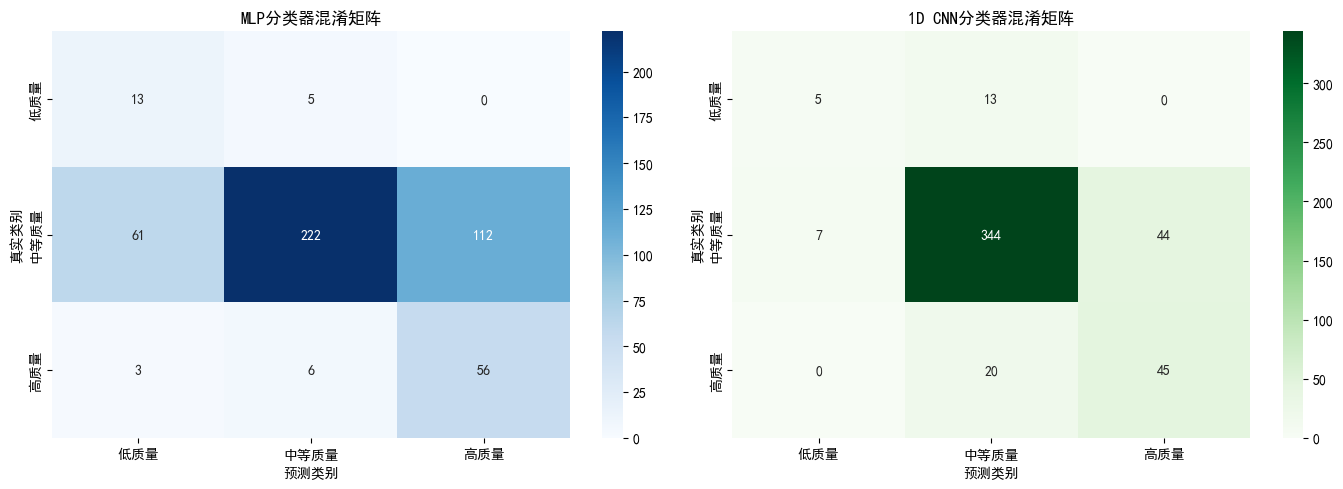

In [47]:
# ==================== 深度学习模型性能评估 ====================
print("\n" + "=" * 50)
print("深度学习模型性能评估")
print("=" * 50)

# MLP性能
mlp_metrics, mlp_cm = calculate_metrics(mlp_targets, mlp_preds, 3)
print("\nMLP分类器详细性能指标:")
print(f"{'类别':<10} {'精确率':<10} {'召回率':<10} {'F1分数':<10} {'支持度':<10}")
print("-" * 50)
for cls in sorted(mlp_metrics.keys()):
    m = mlp_metrics[cls]
    print(f"{cls:<10} {m['precision']:<10.4f} {m['recall']:<10.4f} {m['f1']:<10.4f} {m['support']:<10}")

# CNN性能
cnn_metrics, cnn_cm = calculate_metrics(cnn_targets, cnn_preds, 3)
print("\n1D CNN分类器详细性能指标:")
print(f"{'类别':<10} {'精确率':<10} {'召回率':<10} {'F1分数':<10} {'支持度':<10}")
print("-" * 50)
for cls in sorted(cnn_metrics.keys()):
    m = cnn_metrics[cls]
    print(f"{cls:<10} {m['precision']:<10.4f} {m['recall']:<10.4f} {m['f1']:<10.4f} {m['support']:<10}")

# 可视化混淆矩阵对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MLP混淆矩阵
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['低质量', '中等质量', '高质量'],
            yticklabels=['低质量', '中等质量', '高质量'])
axes[0].set_xlabel('预测类别')
axes[0].set_ylabel('真实类别')
axes[0].set_title('MLP分类器混淆矩阵')

# CNN混淆矩阵
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['低质量', '中等质量', '高质量'],
            yticklabels=['低质量', '中等质量', '高质量'])
axes[1].set_xlabel('预测类别')
axes[1].set_ylabel('真实类别')
axes[1].set_title('1D CNN分类器混淆矩阵')

plt.tight_layout()
plt.savefig('dl_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()



深度学习模型ROC曲线分析
MLP - 类别 0 (低质量) AUC: 0.8347
MLP - 类别 1 (中等质量) AUC: 0.7782
MLP - 类别 2 (高质量) AUC: 0.8565
1D CNN - 类别 0 (低质量) AUC: 0.7284
1D CNN - 类别 1 (中等质量) AUC: 0.7688
1D CNN - 类别 2 (高质量) AUC: 0.8614


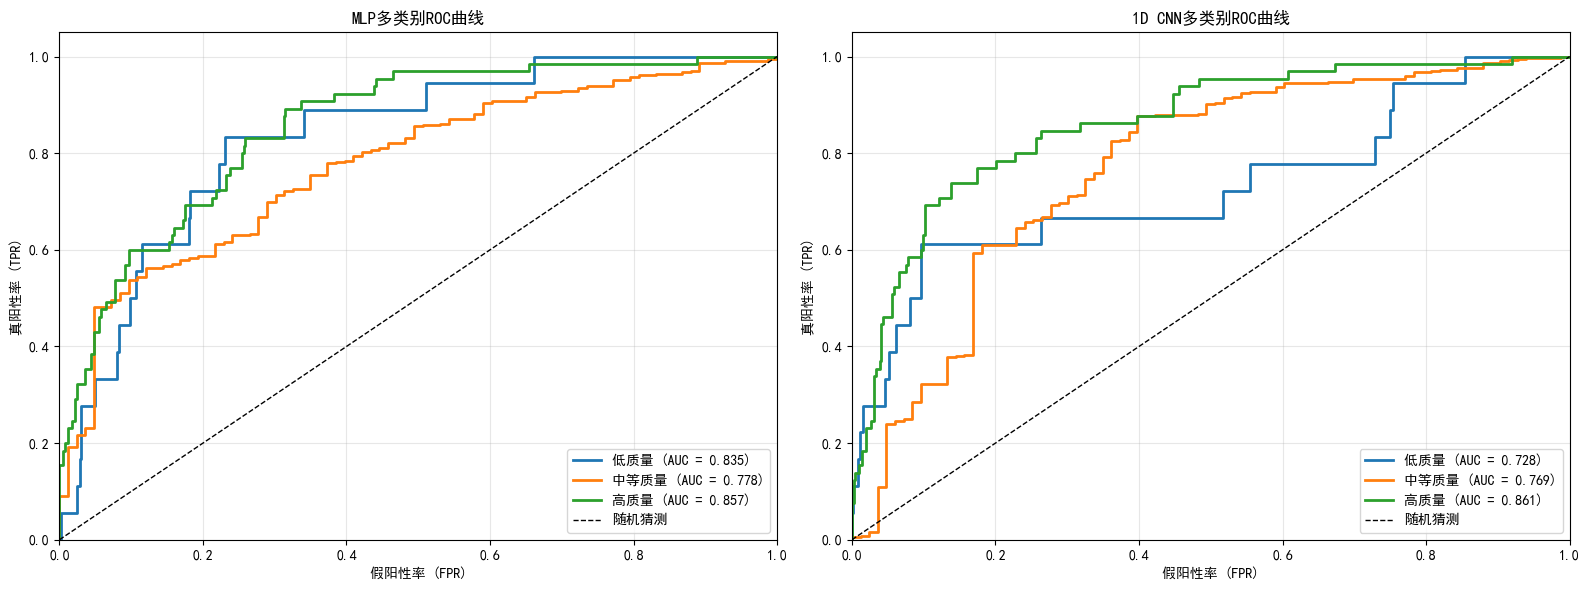

In [48]:
# ==================== 深度学习模型ROC曲线 ====================
print("\n" + "=" * 50)
print("深度学习模型ROC曲线分析")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MLP ROC曲线
for cls in classes:
    y_scores = mlp_probs[:, cls]
    fpr, tpr, _ = calculate_roc_curve(mlp_targets, y_scores, cls)
    auc_score = calculate_auc(fpr, tpr)
    
    class_names = ['低质量', '中等质量', '高质量']
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{class_names[cls]} (AUC = {auc_score:.3f})')
    print(f"MLP - 类别 {cls} ({class_names[cls]}) AUC: {auc_score:.4f}")

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('假阳性率 (FPR)')
axes[0].set_ylabel('真阳性率 (TPR)')
axes[0].set_title('MLP多类别ROC曲线')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# CNN ROC曲线
for cls in classes:
    y_scores = cnn_probs[:, cls]
    fpr, tpr, _ = calculate_roc_curve(cnn_targets, y_scores, cls)
    auc_score = calculate_auc(fpr, tpr)
    
    class_names = ['低质量', '中等质量', '高质量']
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{class_names[cls]} (AUC = {auc_score:.3f})')
    print(f"1D CNN - 类别 {cls} ({class_names[cls]}) AUC: {auc_score:.4f}")

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('假阳性率 (FPR)')
axes[1].set_ylabel('真阳性率 (TPR)')
axes[1].set_title('1D CNN多类别ROC曲线')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dl_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()



所有模型综合性能对比

模型综合性能对比:
模型                   准确率          宏平均F1        加权平均F1      
------------------------------------------------------------
朴素贝叶斯                0.7615       0.5019       0.7715      
逻辑回归                 0.7531       0.4915       0.7656      
MLP (Focal Loss)     0.6088       0.4871       0.6599      
1D CNN (Focal Loss)  0.8243       0.6030       0.8285      


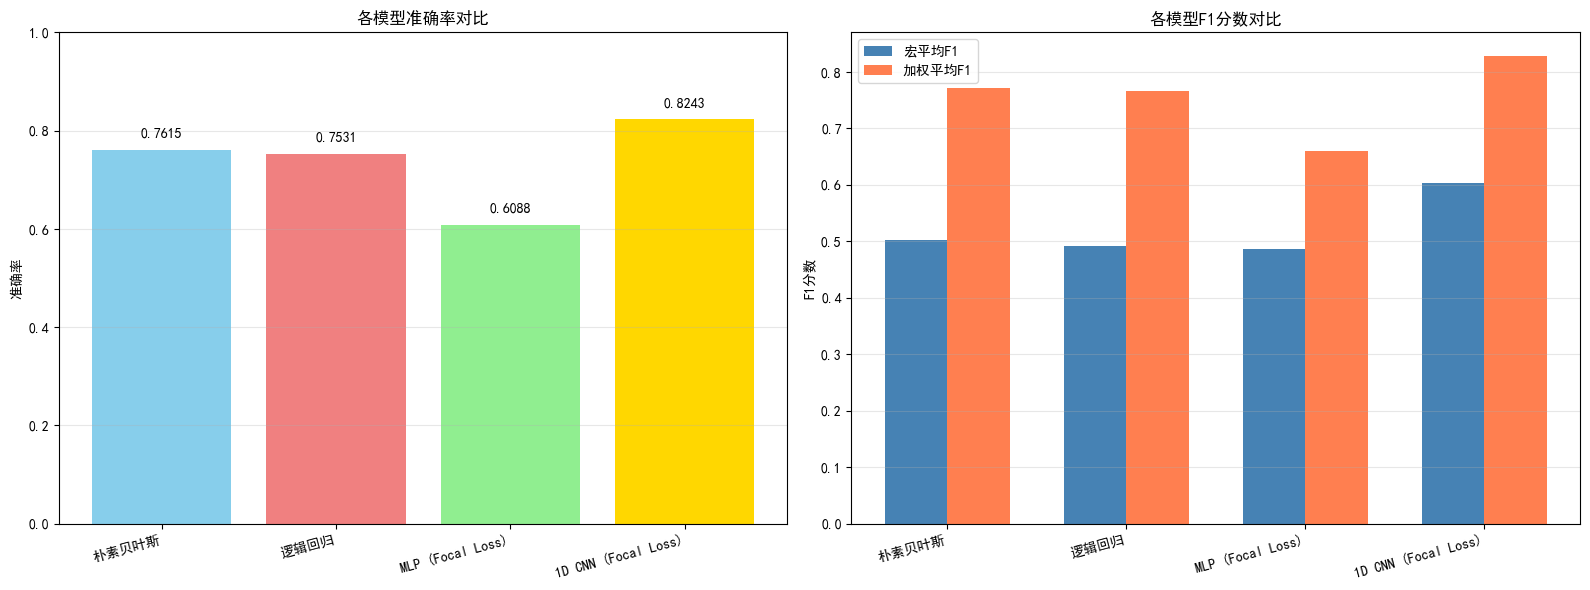

In [49]:
# ==================== 所有模型综合对比 ====================
print("\n" + "=" * 50)
print("所有模型综合性能对比")
print("=" * 50)

# 收集所有模型的结果
all_models_results = {
    '朴素贝叶斯': {
        'accuracy': accuracy_custom,
        'predictions': y_pred_custom,
        'probabilities': y_pred_proba_custom
    },
    '逻辑回归': {
        'accuracy': np.mean(sklearn_nb.predict(X_test_norm) == y_test),
        'predictions': sklearn_nb.predict(X_test_norm),
        'probabilities': sklearn_nb.predict_proba(X_test_norm)
    },
    'MLP (Focal Loss)': {
        'accuracy': mlp_acc / 100,
        'predictions': mlp_preds,
        'probabilities': mlp_probs
    },
    '1D CNN (Focal Loss)': {
        'accuracy': cnn_acc / 100,
        'predictions': cnn_preds,
        'probabilities': cnn_probs
    }
}

# 计算各模型的F1分数
from sklearn.metrics import f1_score

print("\n模型综合性能对比:")
print(f"{'模型':<20} {'准确率':<12} {'宏平均F1':<12} {'加权平均F1':<12}")
print("-" * 60)

for model_name, results in all_models_results.items():
    acc = results['accuracy']
    preds = results['predictions']
    macro_f1 = f1_score(y_test, preds, average='macro')
    weighted_f1 = f1_score(y_test, preds, average='weighted')
    
    print(f"{model_name:<20} {acc:<12.4f} {macro_f1:<12.4f} {weighted_f1:<12.4f}")

# 绘制综合对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 准确率对比
model_names = list(all_models_results.keys())
accuracies = [all_models_results[name]['accuracy'] for name in model_names]

axes[0].bar(range(len(model_names)), accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylabel('准确率')
axes[0].set_title('各模型准确率对比')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# 为每个柱子添加数值标签
for i, acc in enumerate(accuracies):
    axes[0].text(i, acc + 0.02, f'{acc:.4f}', ha='center', va='bottom')

# F1分数对比
macro_f1s = [f1_score(y_test, all_models_results[name]['predictions'], average='macro') 
             for name in model_names]
weighted_f1s = [f1_score(y_test, all_models_results[name]['predictions'], average='weighted') 
                for name in model_names]

x = np.arange(len(model_names))
width = 0.35

axes[1].bar(x - width/2, macro_f1s, width, label='宏平均F1', color='steelblue')
axes[1].bar(x + width/2, weighted_f1s, width, label='加权平均F1', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
axes[1].set_ylabel('F1分数')
axes[1].set_title('各模型F1分数对比')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
